### Load Model SmartShield


In [2]:
import joblib

model = joblib.load("smartshield-V1.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


In [3]:
import pandas as pd

data = pd.read_csv("pe_features.csv")   # your dataset

X = data.drop("malware", axis=1)   # features
y = data["malware"]                # target (0=Benign, 1=Malware)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

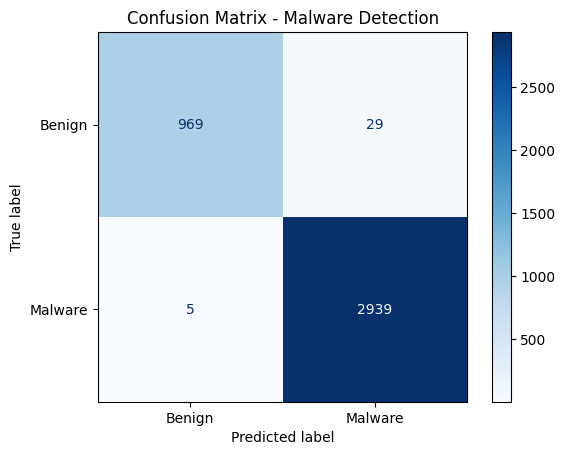

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict
y_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign","Malware"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Malware Detection")

plt.show()

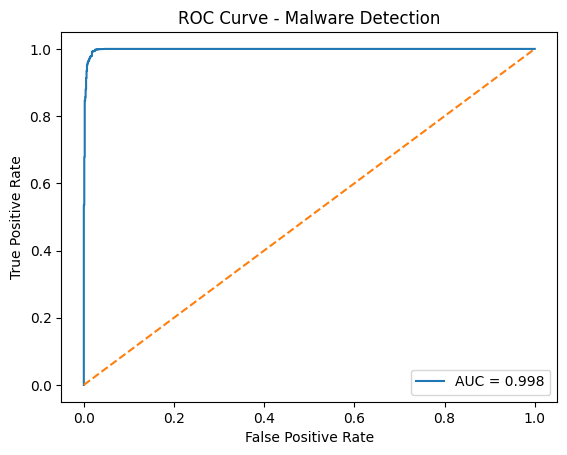

In [6]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label="AUC = %0.3f" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Malware Detection")

plt.legend(loc="lower right")

plt.show()

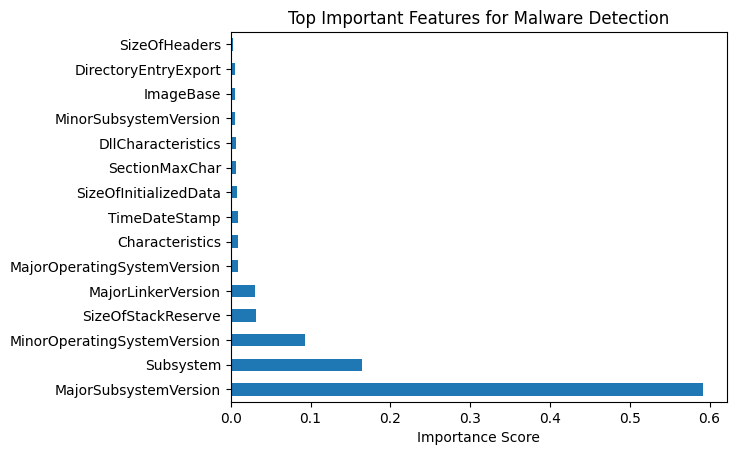

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model.feature_importances_

feature_names = X_train.columns

feat_importance = pd.Series(importance, index=feature_names)

feat_importance.nlargest(15).plot(kind='barh')

plt.title("Top Important Features for Malware Detection")

plt.xlabel("Importance Score")

plt.show()

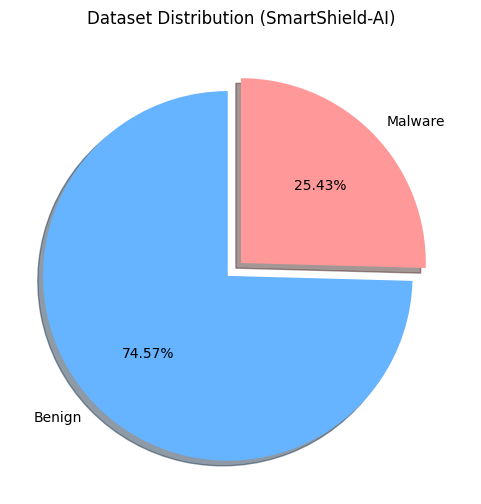

In [6]:
import matplotlib.pyplot as plt

counts = y.value_counts()

labels = ["Benign","Malware"]

plt.figure(figsize=(6,6))

plt.pie(counts,
        labels=labels,
        autopct='%1.2f%%',
        startangle=90,shadow=True, explode=(0.1,0) , colors=['#66b3ff','#ff9999'])

plt.title("Dataset Distribution (SmartShield-AI)")

plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

rf = RandomForestClassifier()
svm = SVC(probability=True)

models = {
    "Random Forest": rf,
    "SVM": svm,
    "XGBoost": model
}

scores = []

for name, m in models.items():
    score = cross_val_score(m, X_train, y_train, cv=5).mean()
    scores.append(score)

plt.bar(models.keys(), scores)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

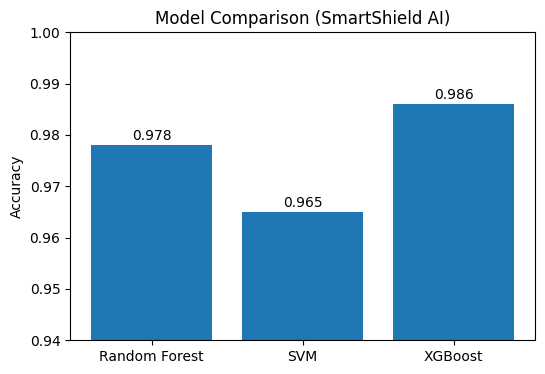

In [ ]:
import matplotlib.pyplot as plt

models = ["Random Forest","SVM","XGBoost"]
scores = [0.978, 0.965, 0.986]

plt.figure(figsize=(6,4))

bars = plt.bar(models, scores)

# Zoom the y-axis to highlight differences
plt.ylim(0.94, 1.00)

# Add accuracy labels on bars
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             score + 0.001,
             f"{score:.3f}",
             ha='center')

plt.ylabel("Accuracy")
plt.title("Model Comparison (SmartShield AI)")

plt.show()

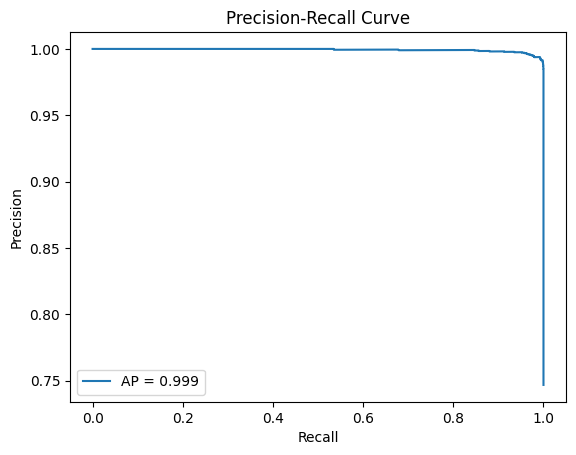

In [ ]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

y_prob = model.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

ap_score = average_precision_score(y_test, y_prob)

plt.figure()

plt.plot(recall, precision, label=f"AP = {ap_score:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.show()

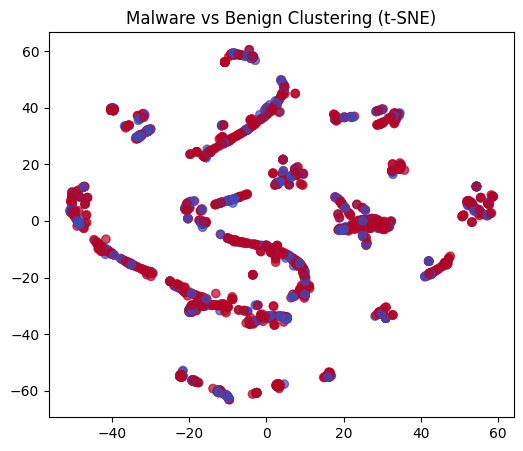

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42)

X_embedded = tsne.fit_transform(X_train.sample(2000))

plt.figure(figsize=(6,5))

plt.scatter(X_embedded[:,0],
            X_embedded[:,1],
            c=y_train.sample(2000),
            cmap="coolwarm",
            alpha=0.7)

plt.title("Malware vs Benign Clustering (t-SNE)")

plt.show()

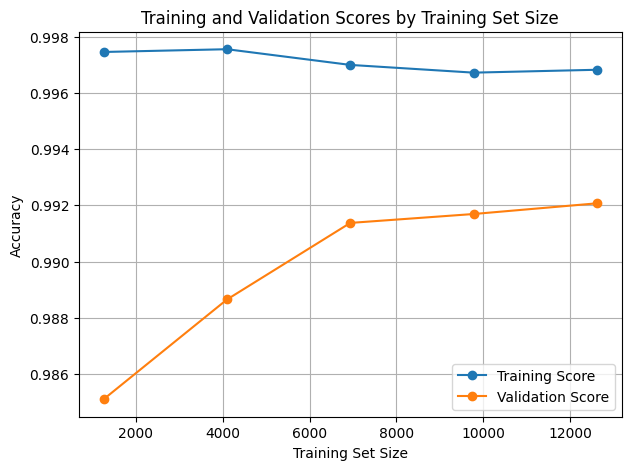

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Generate learning curve
train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_train,
    y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Compute averages
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# Plot
plt.figure(figsize=(7,5))

plt.plot(train_sizes, train_mean, marker='o', label="Training Score")
plt.plot(train_sizes, val_mean, marker='o', label="Validation Score")

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Training and Validation Scores by Training Set Size")

plt.legend()
plt.grid()

plt.show()